In [15]:
import jax
import jax.numpy as jnp
import functions
import pybamm
import numpy as np

In [16]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Chen2020")
# params_bat["Lower voltage cut-off [V]"] = -100.0
# params_bat["Upper voltage cut-off [V]"] = 100.0
# params_bat["Maximum concentration in negative electrode [mol.m-3]"] = 100e6
# params_bat["Maximum concentration in positive electrode [mol.m-3]"] = 100e6
# # params_bat["Minimum concentration in negative electrode [mol.m-3]"] = -100e6
# # params_bat["Minimum concentration in positive electrode [mol.m-3]"] = -100e6


# Hyperparameters
num_train = 22
num_test = 2

C = params_bat["Nominal cell capacity [A.h]"]

t_max = 3600
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [17]:
spm = pybamm.lithium_ion.SPM()
spm.events = []
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]

def get_targets(I_samples, socs=[0.5]):
    set_targets = []
    set_c0 = []

    I_pruned = []

    #fast_solver = pybamm.CasadiSolver(atol=1e-3, rtol=1e-3, mode="fast")
    
    for soc in socs:
        for id, I_func in enumerate(I_samples):
            # Update parameter
            params_bat = pybamm.ParameterValues("Chen2020")
            params_bat["Current function [A]"] = pybamm.Interpolant(t, -1.* I_func, pybamm.t)
            params_bat["Negative particle diffusivity [m2.s-1]"] = 3.3e-14
            params_bat["Positive particle diffusivity [m2.s-1]"] = 4e-15

            # Re-create the simulation with updated parameters
            sim = pybamm.Simulation(spm, parameter_values=params_bat)#, solver=fast_solver)
            sol = sim.solve(initial_soc=soc, t_eval=t)

            c0 = sol["Negative particle concentration"].entries[:,0,0]
            cn_target = sol["Negative particle concentration"].entries[:,0,:]

            if cn_target.shape[-1] != num_samples_I:
                continue
            else:
                I_pruned.append(I_func)

            #I_pruned.append(I_func)
            
            set_targets.append(cn_target)
            set_c0.append(c0)

    
    return set_targets, set_c0, I_pruned


# def generate_data(key, num):
#     keys = jax.random.split(key, num)
#     func_I = []
#     for k in keys:
#         # Generate a random current function
#         I_func = functions.GaussianRFCurrent(k, C, t_max)
#         func_I.append(I_func(t))
#     return func_I

# def generate_data(key, num):
#     keys = jax.random.split(key, num)
#     train_I = []
#     for k in keys:
#         # Sample a random amplitude value for the triangle current
#         value = jax.random.uniform(k, shape=(), minval=-1, maxval=1)
#         I_func = functions.TriangleCurrent(value * C)
#         train_I.append(I_func(t))
#     return train_I

def generate_data(key, num_samples):
    keys = jax.random.split(key, num_samples)
    set_I = []
    for k in keys:
        # Generate a random constant current value between -1C and 1C
        rand_value = jax.random.uniform(k, shape=(), minval=-1, maxval=1)
        
        # Create a constant current function with that value
        I_func = functions.ConstantCurrent(rand_value*C)
        # Evaluate at times t and append
        set_I.append(I_func(t))
    return set_I

In [18]:
train_I = generate_data(key_train, num_train)
test_I = generate_data(key_test, num_test)
train_cn, train_c0, train_I = get_targets(train_I)
test_cn, test_c0, test_I = get_targets(test_I)

train_I = np.array(train_I)
test_I = np.array(test_I)
train_cn = np.array(train_cn)
test_cn = np.array(test_cn)
train_c0 = np.array(train_c0)
test_c0 = np.array(test_c0)

In [29]:
shapes = [i.shape for i in train_cn]

In [30]:
len(shapes)

22

In [31]:
filename = ""
path = "data/spm/"
np.savez(path + "train/" + filename + ".npz", current=train_I, initial_concentration=train_c0, target_concentration=train_cn)
np.savez(path + "test/" + filename + ".npz", current=test_I, initial_concentration=test_c0, target_concentration=test_cn)

In [32]:
train_data = np.load(path + "train/" + filename + ".npz")
test_data = np.load(path + "test/" + filename + ".npz")

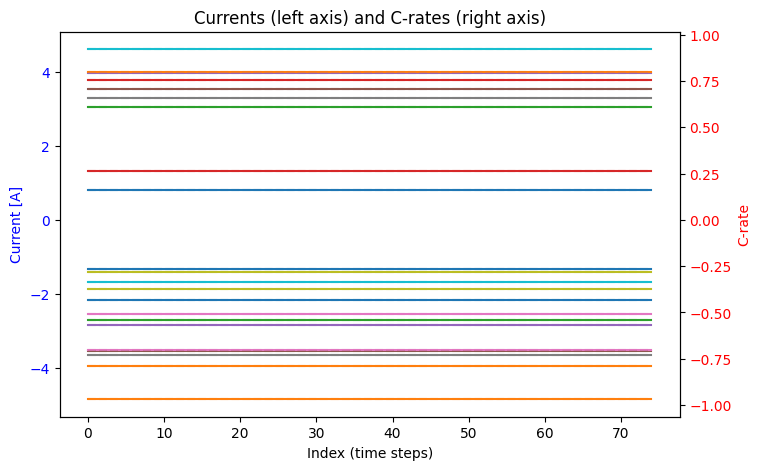

In [39]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# Suppose train_data["current"] is a numpy array of shape (14, 75),
# and we have some known battery capacity in ampere-hours, e.g. C = 5.0
data = train_data["current"]

# Create a figure with one Axes, then a twin Axes for second scale
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot the currents on ax1
for i in range(data.shape[0]):
    ax1.plot(data[i, :], label=f"Series {i}")

ax1.set_xlabel("Index (time steps)")
ax1.set_ylabel("Current [A]", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# Create second y‐axis for the C‐rate
ax2 = ax1.twinx()
for i in range(data.shape[0]):
    # Convert current [A] into C‐rate by dividing by capacity [Ah]
    # (If your capacity is in different units, adjust accordingly)
    c_rate = data[i, :] / C
    ax2.plot(c_rate, linestyle="--", alpha=0.7)

ax2.set_ylabel("C-rate", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Currents (left axis) and C-rates (right axis)")
plt.show()


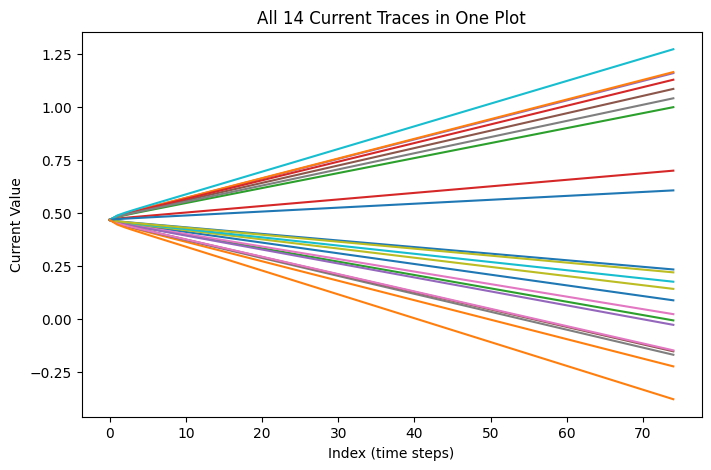

In [34]:
data = train_data["target_concentration"]

plt.figure(figsize=(8, 5))

for i in range(data.shape[0]):  # i goes from 0 to 13
    plt.plot(data[i,-1, :], label=f"Series {i}")

plt.xlabel("Index (time steps)")
plt.ylabel("Current Value")
plt.title("All 14 Current Traces in One Plot")
#plt.legend()
plt.show()

In [35]:
train_cn.shape

(22, 20, 75)

In [36]:
mins = [i[-1,:].min() for i in train_cn]
maxs = [i[-1,:].max() for i in train_cn]

In [37]:
maxs

[0.4684797105314332,
 0.4684797105314332,
 0.4684797105314332,
 0.7006367454859446,
 1.1602844008702204,
 1.085988308345626,
 0.4684797105314332,
 0.4684797105314332,
 0.4684797105314332,
 0.4684797105314332,
 0.4684797105314332,
 1.1654219917902224,
 0.9999363127529994,
 1.1293290478134763,
 0.4684797105314332,
 0.4684797105314332,
 0.4684797105314332,
 1.0417489013159398,
 0.4684797105314332,
 1.2730559465348936,
 0.6075574607946878,
 0.4684797105314332]

In [38]:
train_cn[-3][-1,:]

array([0.46847971, 0.48948662, 0.50211425, 0.51351145, 0.52447571,
       0.53527332, 0.54600638, 0.55671399, 0.56741165, 0.57810579,
       0.58879869, 0.59949108, 0.61018204, 0.6208734 , 0.63156485,
       0.64225635, 0.65294786, 0.66363938, 0.67433089, 0.68502241,
       0.69571393, 0.70640545, 0.71709697, 0.72778849, 0.73848001,
       0.74917152, 0.75986304, 0.77055456, 0.78124608, 0.7919376 ,
       0.80262912, 0.81332064, 0.82401216, 0.83470368, 0.84539519,
       0.85608671, 0.86677823, 0.87746975, 0.88816127, 0.89885279,
       0.90954431, 0.92023583, 0.93092734, 0.94161886, 0.95231038,
       0.9630019 , 0.97369342, 0.98438494, 0.99507646, 1.00576798,
       1.01645949, 1.02715101, 1.03784253, 1.04853405, 1.05922557,
       1.06991709, 1.08060861, 1.09130013, 1.10199165, 1.11268316,
       1.12337468, 1.1340662 , 1.14475772, 1.15544924, 1.16614076,
       1.17683228, 1.1875238 , 1.19821531, 1.20890683, 1.21959835,
       1.23028987, 1.24098139, 1.25167291, 1.26236443, 1.27305